# Notebook 15 — DBSCAN

En este notebook estudiaremos **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**, un algoritmo de clustering basado en densidad que no requiere especificar el número de grupos y que además puede identificar observaciones atípicas (*outliers*).

## Objetivos

Al finalizar este notebook serás capaz de:

- comprender la intuición detrás de DBSCAN;
- interpretar los parámetros `eps` y `min_samples`;
- distinguir puntos núcleo, borde y ruido;
- ajustar DBSCAN con `scikit-learn`;
- comparar DBSCAN contra K-Means;
- estudiar el efecto de los hiperparámetros;
- identificar ventajas y limitaciones del algoritmo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42


## 1. Dataset con forma no convexa

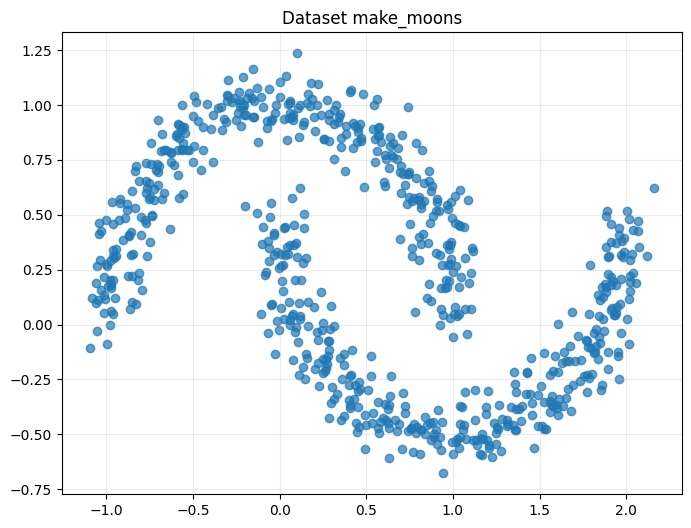

In [2]:
X, _ = make_moons(
    n_samples=700,
    noise=0.08,
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], alpha=.7)
plt.title("Dataset make_moons")
plt.grid(alpha=.25)
plt.show()



## 2. ¿Cómo funciona DBSCAN?

DBSCAN utiliza dos hiperparámetros:

- **eps**: radio de vecindad.
- **min_samples**: número mínimo de vecinos para formar una región densa.

Cada observación puede clasificarse como:

- Punto núcleo.
- Punto borde.
- Ruido (outlier).


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(
    eps=0.25,
    min_samples=8,
)

labels = dbscan.fit_predict(X_scaled)

unique_labels = np.unique(labels)
print("Clusters encontrados:", unique_labels)
print("Número de clusters:", len(unique_labels) - (1 if -1 in unique_labels else 0))
print("Outliers:", np.sum(labels==-1))


Clusters encontrados: [-1  0  1]
Número de clusters: 2
Outliers: 1


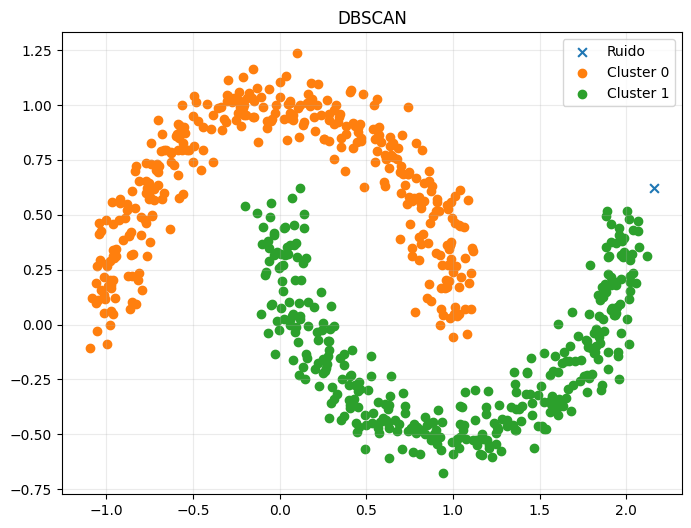

In [4]:
plt.figure(figsize=(8,6))

for c in np.unique(labels):
    mask = labels==c
    if c==-1:
        plt.scatter(
            X[mask,0],
            X[mask,1],
            marker="x",
            s=40,
            label="Ruido"
        )
    else:
        plt.scatter(
            X[mask,0],
            X[mask,1],
            label=f"Cluster {c}"
        )

plt.legend()
plt.title("DBSCAN")
plt.grid(alpha=.25)
plt.show()


## 3. Comparación con K-Means

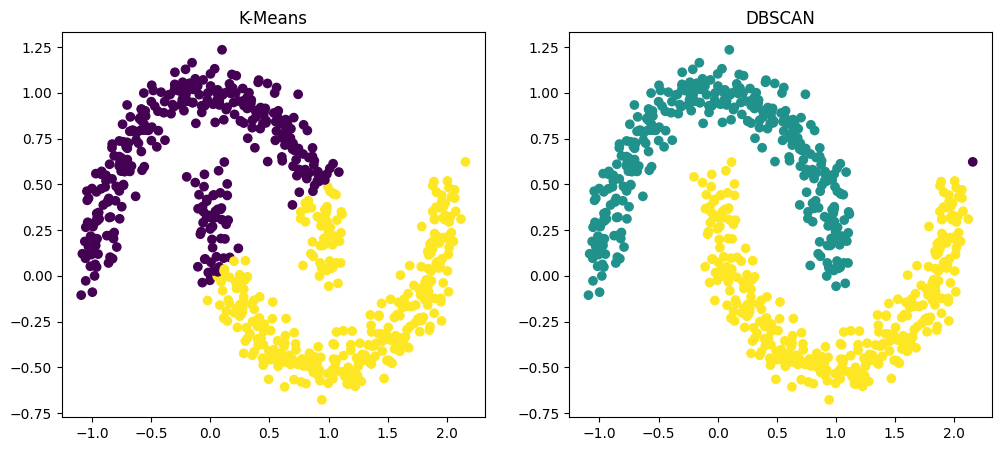

In [5]:
kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=20,
)

k_labels = kmeans.fit_predict(X_scaled)

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(
    X[:,0],
    X[:,1],
    c=k_labels
)
ax[0].set_title("K-Means")

ax[1].scatter(
    X[:,0],
    X[:,1],
    c=labels
)
ax[1].set_title("DBSCAN")

plt.show()



En este conjunto de datos, K-Means intenta construir regiones aproximadamente circulares, mientras que DBSCAN puede recuperar formas curvas al basarse en densidad.


## 4. Sensibilidad a `eps`

In [6]:
eps_values = [0.10,0.15,0.20,0.25,0.35,0.50]

results=[]

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=8
    )

    lbl = model.fit_predict(X_scaled)

    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise = np.sum(lbl==-1)

    if n_clusters>1:
        mask = lbl!=-1
        sil = silhouette_score(
            X_scaled[mask],
            lbl[mask]
        )
    else:
        sil = np.nan

    results.append({
        "eps":eps,
        "Clusters":n_clusters,
        "Outliers":noise,
        "Silhouette":sil
    })

pd.DataFrame(results)


,eps,Clusters,Outliers,Silhouette
0,0.10,24,306,0.483475
1,0.15,6,49,0.062137
2,0.20,2,9,0.389015
3,0.25,2,1,0.382258
4,0.35,1,0,NaN
5,0.50,1,0,NaN


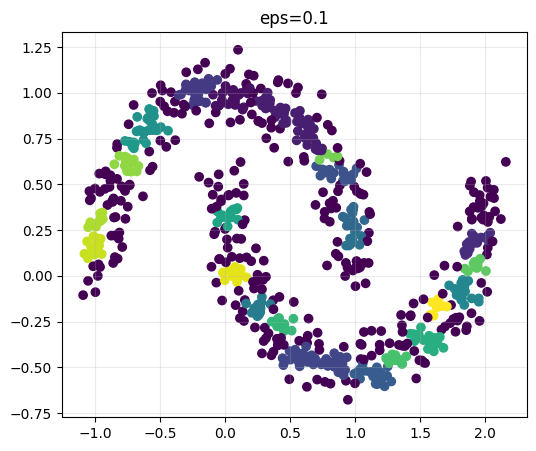

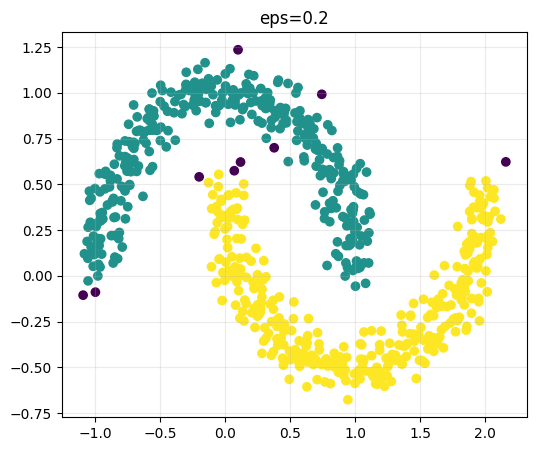

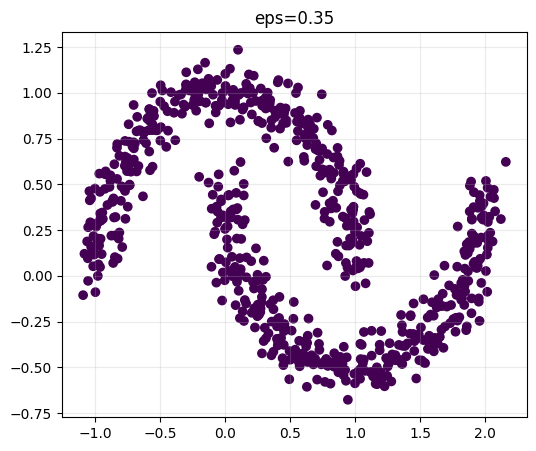

In [7]:
for eps in [0.10,0.20,0.35]:

    model = DBSCAN(
        eps=eps,
        min_samples=8
    )

    lbl=model.fit_predict(X_scaled)

    plt.figure(figsize=(6,5))
    plt.scatter(
        X[:,0],
        X[:,1],
        c=lbl
    )
    plt.title(f"eps={eps}")
    plt.grid(alpha=.25)
    plt.show()


## 5. Sensibilidad a `min_samples`

In [8]:
rows=[]

for m in [3,5,8,12,20]:

    model=DBSCAN(
        eps=0.25,
        min_samples=m
    )

    lbl=model.fit_predict(X_scaled)

    rows.append({
        "min_samples":m,
        "Clusters":len(set(lbl))-(1 if -1 in lbl else 0),
        "Outliers":np.sum(lbl==-1)
    })

pd.DataFrame(rows)


,min_samples,Clusters,Outliers
0,3,2,1
1,5,2,1
2,8,2,1
3,12,2,2
4,20,2,15



## 6. Dataset con outliers


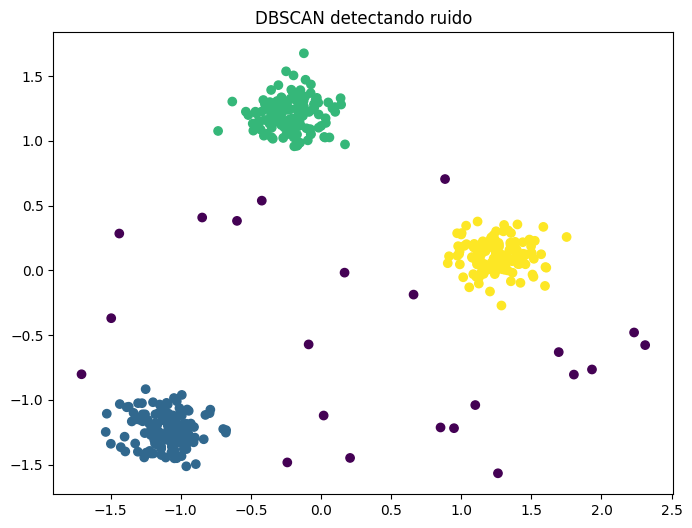

Outliers detectados: 22


In [9]:
X_blob,_ = make_blobs(
    n_samples=400,
    centers=3,
    cluster_std=0.8,
    random_state=RANDOM_STATE
)

outliers = np.random.uniform(
    low=-10,
    high=10,
    size=(25,2)
)

X_blob = np.vstack([X_blob,outliers])

X_blob = StandardScaler().fit_transform(X_blob)

db = DBSCAN(
    eps=0.30,
    min_samples=6
)

lbl=db.fit_predict(X_blob)

plt.figure(figsize=(8,6))
plt.scatter(
    X_blob[:,0],
    X_blob[:,1],
    c=lbl
)
plt.title("DBSCAN detectando ruido")
plt.show()

print("Outliers detectados:", np.sum(lbl==-1))



## 7. Ventajas

- No requiere especificar \(K\).
- Detecta ruido automáticamente.
- Encuentra clusters con formas arbitrarias.
- Funciona bien cuando los grupos están definidos por densidad.

## 8. Limitaciones

- Sensible a `eps`.
- Difícil cuando existen densidades muy distintas.
- Pierde desempeño en alta dimensión.
- No siempre existe un valor claro para `eps`.



## 9. Errores frecuentes

1. No escalar las variables.
2. Elegir `eps` arbitrariamente.
3. Pensar que todos los puntos deben pertenecer a un cluster.
4. Comparar directamente etiquetas entre ejecuciones.
5. Utilizar Silhouette incluyendo el ruido.



## 10. Experimentos sugeridos

1. Cambia `eps` entre 0.05 y 0.6.
2. Cambia `min_samples`.
3. Compara con K-Means sobre `make_blobs`.
4. Incrementa el ruido del dataset.
5. Agrega muchos outliers.
6. Prueba DBSCAN sobre datos de mayor dimensión.



## Resumen

En este notebook:

- estudiamos la intuición de DBSCAN;
- identificamos puntos núcleo, borde y ruido;
- analizamos los efectos de `eps` y `min_samples`;
- comparamos DBSCAN contra K-Means;
- mostramos cómo detectar outliers;
- discutimos cuándo conviene utilizar este algoritmo.

DBSCAN suele ser la mejor alternativa cuando los grupos poseen formas complejas y cuando la detección de observaciones atípicas es parte importante del problema.
